In [1]:
from torchvision import datasets

data_path = './'

cifar10 = datasets.CIFAR10(data_path, train=True, download=True)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True) # train=False означает получение проверочного рабора данных

/home/avtotka/.pyenv/versions/3.14.2/envs/pytorch-learn/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [2]:
len(cifar10)

50000

In [3]:
from matplotlib import pyplot as plt

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

img, label = cifar10[99]
img, label, class_names[label]

(<PIL.Image.Image image mode=RGB size=32x32>, 1, 'automobile')

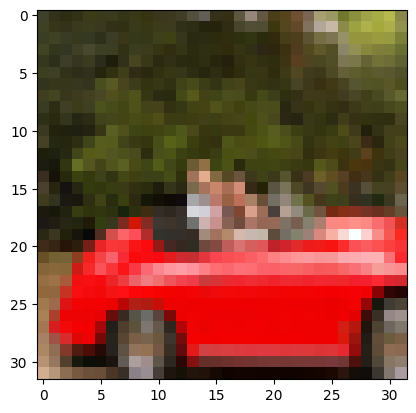

In [4]:
plt.imshow(img)
plt.show()

In [5]:
from torchvision import transforms
dir(transforms)

['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

In [6]:
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t.shape

torch.Size([3, 32, 32])

In [7]:
tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False, transform=transforms.ToTensor())

/home/avtotka/.pyenv/versions/3.14.2/envs/pytorch-learn/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Нормализация

In [8]:
import torch

imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3) # загружаю весь набор в оперативную память
imgs.shape

torch.Size([3, 32, 32, 50000])

In [9]:
imgs.view(3, -1).mean(dim=1) # view "выпрямляет" пиксели в одно измерение, после чего вычисляется mean от каждого из каналов

tensor([0.4914, 0.4822, 0.4465])

In [10]:
imgs.view(3, -1).std(dim=1)

tensor([0.2470, 0.2435, 0.2616])

In [11]:
transformed_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616))
    ])
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9802876..2.1264887].


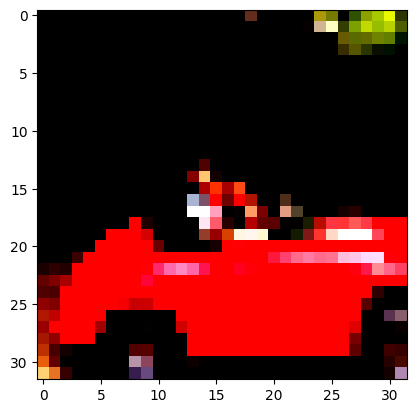

In [12]:
img_t, _ = transformed_cifar10[99]
plt.imshow(img_t.permute(1, 2, 0))
plt.show()

## Отличие птиц и самолётов

In [13]:
cifar10 = transformed_cifar10
cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

In [14]:
label_map = {0: 0, 2: 1} # 0 - самолёты, 2 - птицы
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0, 2]]
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0, 2]]

In [15]:
import torch.nn as nn

n_out = 2
model = nn.Sequential(
    nn.Linear(3072, 1024), # 3072 - вытянутое в одну строку изображение
    nn.Tanh(),
    nn.Linear(1024, 512),
    nn.Tanh(),
    nn.Linear(512, 128),
    nn.Tanh(),
    nn.Linear(128, n_out),
    #nn.LogSoftmax(dim=1) # по строкам
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594..2.0298588].


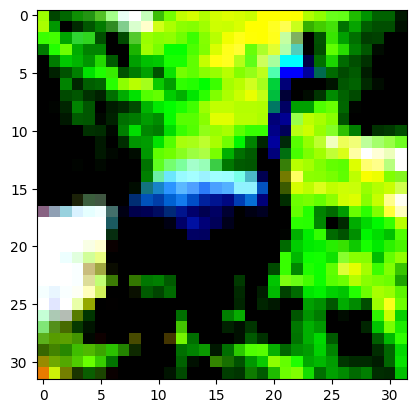

In [16]:
img, _ = cifar2[0]
plt.imshow(img.permute(1, 2, 0))
plt.show()

In [17]:
#img_batch = img.view(-1).unsqueeze(0)

#out = model(img_batch)
#out

In [18]:
#_, index = torch.max(out, dim=1)
#index

In [19]:
img, label = cifar2[0]

out = model(img.view(-1).unsqueeze(0))
loss_fn = nn.CrossEntropyLoss()
loss_fn(out, torch.tensor([label]))

tensor(0.8093, grad_fn=<NllLossBackward0>)

Цикл обучения классификатора 

In [20]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
n_epochs = 100
device = torch.device('cuda')
model = model.to(device)

imgs = torch.stack([img for img, _ in cifar2]).to(device)
labels = torch.tensor([label for _, label in cifar2], device=device)

dataset = TensorDataset(imgs, labels)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

for epoch in range(n_epochs):
    for img_batch, label_batch in loader:
        out = model(img_batch.flatten(1))
        loss = loss_fn(out, label_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch}, Loss {float(loss)}')

/tmp/ipykernel_11126/2227473236.py:23: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f'Epoch {epoch}, Loss {float(loss)}')


Epoch 0, Loss 0.4070020020008087
Epoch 1, Loss 0.5536250472068787
Epoch 2, Loss 0.5196760892868042
Epoch 3, Loss 0.40625137090682983
Epoch 4, Loss 0.456743985414505
Epoch 5, Loss 0.33009621500968933
Epoch 6, Loss 0.43811604380607605
Epoch 7, Loss 0.6796042919158936
Epoch 8, Loss 0.39206090569496155
Epoch 9, Loss 0.4214926064014435
Epoch 10, Loss 0.5491037368774414
Epoch 11, Loss 0.5052899718284607
Epoch 12, Loss 0.5016922950744629
Epoch 13, Loss 0.447870135307312
Epoch 14, Loss 0.4985235333442688
Epoch 15, Loss 0.41456371545791626
Epoch 16, Loss 0.24592941999435425
Epoch 17, Loss 0.46650880575180054
Epoch 18, Loss 0.17285190522670746
Epoch 19, Loss 0.4076949954032898
Epoch 20, Loss 0.13544461131095886
Epoch 21, Loss 0.4007214307785034
Epoch 22, Loss 0.28697583079338074
Epoch 23, Loss 0.260577917098999
Epoch 24, Loss 0.24009248614311218
Epoch 25, Loss 0.8576983213424683
Epoch 26, Loss 0.19102656841278076
Epoch 27, Loss 0.16523104906082153
Epoch 28, Loss 0.08129139244556427
Epoch 29, Los

Проверка модели вычислением уровня безошибочности модели

In [21]:
imgs_val = torch.stack([img for img, _ in cifar2_val]).to(device)
labels_val = torch.tensor([label for _, label in cifar2_val], device=device)

model = model.to('cpu')
val_loader = DataLoader(cifar2_val, batch_size=64, shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        batch_size = imgs.shape[0]
        outputs = model(imgs.view(batch_size, -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print(f'Accurancy {correct/total}')

Accurancy 0.815


In [23]:
# parametes - общее число параметров модели 
# numel - сколько элементов в каждом из экземпляров тензоров
numel_list = [p.numel() for p in model.parameters() if p.requires_grad == True]
sum(numel_list), numel_list

(3737474, [3145728, 1024, 524288, 512, 65536, 128, 256, 2])